# De Neuronas Biológicas a Neuronas Artificiales



Sorprendentemente, las RNA (redes neuronales artificiales) llevan bastante tiempo entre nosotros: fueron presentadas por primera vez en 1943 por el neurofisiólogo Warren McCulloch y el matemático Walter Pitts. 

En su artículo histórico, "A Logical Calculus of Ideas Immanent in Nervous Activity" ("Un cálculo lógico de las ideas inmanentes en la actividad nerviosa"), McCulloch y Pitts presentaron un modelo computacional simplificado de cómo las neuronas biológicas podrían trabajar juntas en los cerebros animales para realizar cálculos complejos mediante lógica proposicional. 

Esta fue la primera arquitectura de red neuronal artificial. 

Desde entonces se han inventado muchas otras arquitecturas, como verás más adelante.



Los primeros éxitos de las RNA llevaron a la creencia generalizada de que pronto estaríamos conversando con máquinas verdaderamente inteligentes. 

Cuando quedó claro en la década de 1960 que esta promesa no se cumpliría (al menos durante bastante tiempo), la financiación se desvió hacia otros campos, y las RNA entraron en un largo invierno. 

A principios de la década de 1980 se inventaron nuevas arquitecturas y se desarrollaron mejores técnicas de entrenamiento, lo que despertó un renovado interés por el conexionismo, el estudio de las redes neuronales. 

Pero el progreso fue lento, y hacia la década de 1990 se habían inventado otras técnicas de aprendizaje automático muy potentes, como las máquinas de vectores de soporte. 

Estas técnicas parecían ofrecer mejores resultados y bases teóricas más sólidas que las RNA, así que una vez más el estudio de las redes neuronales quedó en pausa.



Actualmente estamos siendo testigos de una nueva ola de interés en las RNA. 

¿Se extinguirá esta ola como las anteriores? 

Bueno, aquí van algunas buenas razones para creer que esta vez es diferente y que el renovado interés en las RNA tendrá un impacto mucho más profundo en nuestras vidas:



• Ahora existe una enorme cantidad de datos disponibles para entrenar redes neuronales, y las RNA frecuentemente superan a otras técnicas de aprendizaje automático en problemas muy grandes y complejos.



• El tremendo aumento en la potencia de cómputo desde la década de 1990 hace posible ahora entrenar grandes redes neuronales en un tiempo razonable. Esto se debe en parte a la ley de Moore (el número de componentes en los circuitos integrados se ha duplicado aproximadamente cada 2 años durante los últimos 50 años), pero también gracias a la industria de los videojuegos, que ha estimulado la producción masiva de potentes unidades de procesamiento gráfico (GPU): las tarjetas GPU se diseñaron inicialmente para acelerar gráficos, pero resulta que las redes neuronales realizan cálculos similares (como multiplicaciones de matrices grandes), por lo que también pueden acelerarse mediante GPU. Además, las plataformas en la nube han puesto este poder al alcance de todos.



• Los algoritmos de entrenamiento han mejorado. Para ser honestos, son solo ligeramente diferentes de los utilizados en la década de 1990, pero estos ajustes relativamente pequeños han tenido un enorme impacto positivo.



• Algunas limitaciones teóricas de las RNA han resultado ser inofensivas en la práctica. Por ejemplo, mucha gente pensaba que los algoritmos de entrenamiento de las RNA estaban condenados porque era probable que se quedaran atascados en óptimos locales, pero resulta que esto no es un gran problema en la práctica, especialmente en redes neuronales más grandes: los óptimos locales a menudo funcionan casi tan bien como el óptimo global.



• La invención de la arquitectura Transformer en 2017 (ver Capítulo 15) ha cambiado las reglas del juego: puede procesar y generar todo tipo de datos (por ejemplo, texto, imágenes, audio), a diferencia de las arquitecturas anteriores más especializadas, y funciona muy bien en una amplia variedad de tareas, desde la robótica hasta el plegamiento de proteínas. Además, escala bastante bien, lo que ha hecho posible entrenar modelos base muy grandes que pueden reutilizarse en muchas tareas diferentes, posiblemente con un poco de ajuste fino (esto es transfer learning o aprendizaje por transferencia), o simplemente indicándole al modelo de la manera correcta (esto es in-context learning o aprendizaje en contexto, ICL). Por ejemplo, puedes darle unos pocos ejemplos de la tarea en cuestión (esto es few-shot learning o aprendizaje con pocos ejemplos, FSL), o pedirle que razone paso a paso (esto es chain-of-thought prompting o instrucciones de cadena de pensamiento, CoT). ¡Es un mundo nuevo!



• Las RNA parecen haber entrado en un círculo virtuoso de financiación y progreso. Productos asombrosos basados en RNA aparecen regularmente en los titulares de noticias, lo que atrae cada vez más atención y financiación hacia ellas, lo que resulta en más progreso y productos aún más asombrosos. La IA ya no solo impulsa productos en las sombras: desde que se lanzaron chatbots como ChatGPT, el público en general ahora interactúa directamente a diario con asistentes de IA, y las grandes empresas tecnológicas compiten ferozmente por conquistar este mercado gigantesco: el ritmo de innovación es vertiginoso.

Aquí tienes una práctica en Python que te permite implementar el modelo original de McCulloch-Pitts (mencionado en el texto) y luego explorar algunos de los conceptos clave: compuertas lógicas con neuronas artificiales, el problema de los óptimos locales, y una demostración conceptual de few-shot / in-context learning.La práctica tiene tres partes conectadas directamente con el texto:



1. **Neurona de McCulloch-Pitts**: implementas la neurona original de 1943 y construyes compuertas AND/OR/NOT con ella. Hay un TODO para XOR, que justamente ilustra por qué las RNA de una sola capa se estancaron en los años 60.
2. **Óptimos locales vs. globales**: una simulación con descenso por gradiente desde múltiples puntos de partida, para comprobar de forma práctica la afirmación del texto de que los óptimos locales "suelen funcionar casi tan bien como el global".
3. **Few-shot / in-context learning**: una analogía simplificada (sin RNA real) para entender la diferencia entre aprender de ejemplos en el prompt vs. reentrenar el modelo.



Al final hay preguntas de reflexión para conectar el código con los conceptos del texto.

"""
PRÁCTICA: De Neuronas Biológicas a Neuronas Artificiales
=========================================================

Esta práctica profundiza en el texto sobre la historia de las RNA
implementando el modelo original de McCulloch-Pitts (1943) y explorando
algunos de los conceptos mencionados: lógica proposicional, óptimos
locales vs. globales, y few-shot/in-context learning.

Cada ejercicio incluye una breve explicación y código para completar
(marcado con TODO) o ya resuelto para que lo ejecutes y experimentes.
"""


In [10]:

import random
import math

# ============================================================
# EJERCICIO 1: La neurona de McCulloch-Pitts (1943)
# ============================================================
# El texto dice que McCulloch y Pitts modelaron cómo las neuronas
# biológicas podrían combinarse para realizar cálculos usando
# "lógica proposicional". Su neurona es muy simple:
#
#   - Recibe una o más entradas binarias (0 o 1)
#   - Suma las entradas (con posibles pesos +1 o -1, o inhibitorias)
#   - Se activa (salida = 1) si la suma alcanza un umbral; si no, salida = 0
#
# Implementemos una neurona genérica de McCulloch-Pitts:

def neurona_mcculloch_pitts(entradas, pesos, umbral):
    """
    entradas: lista de 0s y 1s
    pesos: lista de pesos (mismo tamaño que entradas)
    umbral: valor que debe alcanzar o superar la suma ponderada
    """
    suma = sum(e * p for e, p in zip(entradas, pesos))
    return 1 if suma >= umbral else 0


# Con esta única neurona podemos construir compuertas lógicas,
# tal como proponían McCulloch y Pitts:

def AND(a, b):
    # Ambas entradas deben ser 1 para activarse -> umbral = 2, pesos = 1,1
    return neurona_mcculloch_pitts([a, b], [1, 1], umbral=2)

def OR(a, b):
    # Basta con que una entrada sea 1 -> umbral = 1, pesos = 1,1
    return neurona_mcculloch_pitts([a, b], [1, 1], umbral=1)

def NOT(a):
    # Peso negativo (inhibitorio): si a=1, la suma baja del umbral
    return neurona_mcculloch_pitts([a], [-1], umbral=0)


print("=== Ejercicio 1: Compuertas lógicas con neuronas de McCulloch-Pitts ===")
for x in [0, 1]:
    for y in [0, 1]:
        print(f"AND({x},{y}) = {AND(x, y)}   OR({x},{y}) = {OR(x, y)}")
print(f"NOT(0) = {NOT(0)}   NOT(1) = {NOT(1)}")
print()

# TODO 1: Implementa la compuerta XOR usando varias neuronas de
# McCulloch-Pitts combinadas (una sola neurona NO puede resolver XOR,
# ¡es justo el problema que llevó al primer "invierno" de las RNA!).
# Pista: XOR(a,b) = AND(OR(a,b), NOT(AND(a,b)))

def XOR(a, b):
    # TODO: complétalo usando las funciones AND, OR, NOT ya definidas
    return AND(OR(a,b), NOT(AND(a,b))) 

for x in [0,1]:
    for y in [0,1]:
        print(f'XOR({x}, {y}) = {XOR(x,y)}')

=== Ejercicio 1: Compuertas lógicas con neuronas de McCulloch-Pitts ===
AND(0,0) = 0   OR(0,0) = 0
AND(0,1) = 0   OR(0,1) = 1
AND(1,0) = 0   OR(1,0) = 1
AND(1,1) = 1   OR(1,1) = 1
NOT(0) = 1   NOT(1) = 0

XOR(0, 0) = 0
XOR(0, 1) = 1
XOR(1, 0) = 1
XOR(1, 1) = 0


[Video de apoyo al inicio de la historia sobre las RNA](https://www.youtube.com/watch?v=Ix7NxK-A8NU)

In [ ]:


# ============================================================
# EJERCICIO 2: Óptimos locales vs. globales
# ============================================================
# El texto menciona que mucha gente temía que el entrenamiento de RNA
# quedara "atascado" en óptimos locales, pero en la práctica esto no
# suele ser un problema grave. Vamos a simular esa idea con una
# función simple que tiene varios mínimos locales y un mínimo global.

def funcion_con_optimos(x):
    # Función con varios "valles" (mínimos locales) de distinta profundidad
    return math.sin(x) + 0.1 * x**2 * 0.05 - 0.5 * math.sin(3 * x)


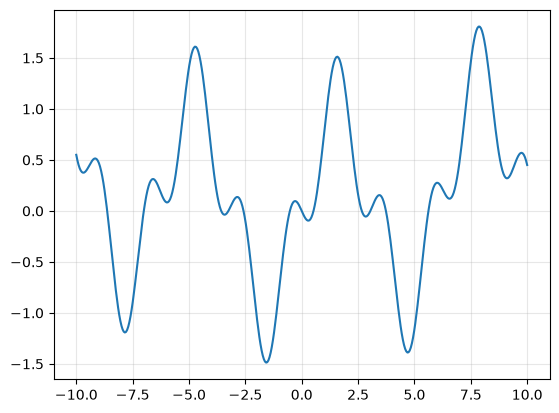

In [15]:
import numpy as np 
import matplotlib.pyplot as plt  

x = np.linspace(-10, 10, 400)
y = [funcion_con_optimos(xi) for xi in x]

plt.plot(x, y)
plt.grid(alpha=0.3) 
plt.savefig(r"C:\Users\marco\Downloads\funcion_con_optimos.png")

In [13]:

def descenso_por_gradiente(x_inicial, tasa_aprendizaje=0.1, pasos=200):
    x = x_inicial
    h = 1e-5
    for _ in range(pasos):
        # derivada numérica (aproximada)
        derivada = (funcion_con_optimos(x + h) - funcion_con_optimos(x - h)) / (2 * h)
        x -= tasa_aprendizaje * derivada
    return x, funcion_con_optimos(x)

print("=== Ejercicio 2: Óptimos locales vs. global ===")
resultados = []
for _ in range(10):
    x0 = random.uniform(-10, 10)  # distintos puntos de partida aleatorios
    x_final, valor_final = descenso_por_gradiente(x0)
    resultados.append((x0, x_final, valor_final))

for x0, xf, vf in resultados:
    print(f"Inicio: {x0:6.2f}  ->  Óptimo encontrado: {xf:6.2f}  (valor: {vf:6.3f})")

mejor = min(resultados, key=lambda r: r[2])
print(f"\nMejor óptimo encontrado (aprox. global): {mejor[1]:.2f} con valor {mejor[2]:.3f}")
print("Observa cuántos puntos de partida terminan cerca del mejor valor:")
print("esto ilustra por qué, en la práctica, los óptimos locales suelen")
print("estar 'casi tan bien' como el óptimo global, tal como dice el texto.\n")

# TODO 2: Cambia el rango de random.uniform(-10, 10) por uno más amplio,
# por ejemplo (-50, 50), y observa si aumenta la variedad de óptimos
# locales encontrados. ¿Qué relación ves con el tamaño de la red /
# problema y la dificultad de quedar atascado en un mal óptimo?


# ============================================================
# EJERCICIO 3: Few-shot learning e in-context learning (conceptual)
# ============================================================
# El texto explica que hoy en día, en vez de reentrenar un modelo,
# podemos "darle unos pocos ejemplos" (few-shot learning) dentro del
# propio prompt para que aprenda el patrón sobre la marcha
# (in-context learning). Aquí NO usamos una RNA real, pero simulamos
# la idea con un "traductor" que aprende un patrón a partir de ejemplos:

def few_shot_traductor(ejemplos, palabra_nueva):
    """
    ejemplos: lista de tuplas (entrada, salida) que muestran el patrón
    palabra_nueva: palabra a la que aplicar el patrón aprendido
    """
    # Patrón simple: aprender una transformación letra por letra
    # basada en el primer ejemplo (esto es una simulación muy básica
    # de "aprender el patrón a partir de contexto")
    entrada_ejemplo, salida_ejemplo = ejemplos[0]
    if len(entrada_ejemplo) == len(salida_ejemplo):
        # ejemplo: mayúsculas -> minúsculas, o similar
        transformacion = [o for i, o in zip(entrada_ejemplo, salida_ejemplo)]
        return palabra_nueva.lower() if salida_ejemplo == entrada_ejemplo.lower() else palabra_nueva

    return "patrón no reconocido"

ejemplos = [("HOLA", "hola"), ("MUNDO", "mundo")]
print("=== Ejercicio 3: Few-shot / in-context learning (simulación) ===")
print(f"Ejemplos dados: {ejemplos}")
print(f"Nueva palabra 'PYTHON' -> {few_shot_traductor(ejemplos, 'PYTHON')}")
print()

# TODO 3: Diseña tus propios "ejemplos" con un patrón distinto
# (por ejemplo, invertir la palabra, o poner la primera letra en
# mayúscula) y adapta few_shot_traductor para reconocerlo.
# Esto es solo una analogía sencilla: los LLM reales usan mecanismos
# de atención (arquitectura Transformer) para lograr esto, no reglas
# if/else como aquí.


# ============================================================
# PREGUNTAS DE REFLEXIÓN (para responder en comentarios o aparte)
# ============================================================
# 1. ¿Por qué una sola neurona de McCulloch-Pitts no puede resolver XOR?
#    ¿Qué te dice esto sobre las limitaciones de los modelos lineales?
#
# 2. En el Ejercicio 2, ¿todos los puntos de partida llegaron al mismo
#    óptimo? ¿Cómo se relaciona esto con la afirmación del texto de que
#    "los óptimos locales often perform almost as well as the global
#    optimum"?
#
# 3. El texto distingue entre transfer learning (ajuste fino) e
#    in-context learning (aprender del prompt sin reentrenar). ¿Qué
#    ventajas y limitaciones crees que tiene cada enfoque?

=== Ejercicio 2: Óptimos locales vs. global ===
Inicio:   0.30  ->  Óptimo encontrado:   0.29  (valor: -0.096)
Inicio:  -8.89  ->  Óptimo encontrado:  -7.84  (valor: -1.192)
Inicio:  -7.19  ->  Óptimo encontrado:  -7.84  (valor: -1.192)
Inicio:   7.31  ->  Óptimo encontrado:   6.55  (valor:  0.119)
Inicio:  -5.32  ->  Óptimo encontrado:  -5.97  (valor:  0.083)
Inicio:  -7.16  ->  Óptimo encontrado:  -7.84  (valor: -1.192)
Inicio:   1.20  ->  Óptimo encontrado:   0.29  (valor: -0.096)
Inicio:  -0.51  ->  Óptimo encontrado:  -1.57  (valor: -1.488)
Inicio:   8.03  ->  Óptimo encontrado:   9.10  (valor:  0.319)
Inicio:  -2.94  ->  Óptimo encontrado:  -3.42  (valor: -0.037)

Mejor óptimo encontrado (aprox. global): -1.57 con valor -1.488
Observa cuántos puntos de partida terminan cerca del mejor valor:
esto ilustra por qué, en la práctica, los óptimos locales suelen
estar 'casi tan bien' como el óptimo global, tal como dice el texto.

=== Ejercicio 3: Few-shot / in-context learning (simulac

In [2]:
import pandas as pd  

df = pd.read_excel(r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\2_meteo_epi_2021-2026_1_rezagos.xlsx")
df 

,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,casos_dengue_lag_3,casos_dengue_lag_4,casos_dengue_lag_5,casos_dengue_lag_6,casos_dengue_lag_7,casos_dengue_lag_8,casos_dengue_lag_9,casos_dengue_lag_10,casos_dengue_lag_11,casos_dengue_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,0,1,0,1,1,0,0,1,0,0
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,0,0,1,0,1,1,0,0,1,0
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,0,0,0,1,0,1,1,0,0,1
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,1,0,0,0,1,0,1,1,0,0
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,0,1,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,2026-05-03,2026,18,27.542857,31.245714,25.042857,20.085714,87.230000,27.43,4,...,31,30,26,27,29,28,47,35,45,29
266,2026-05-10,2026,19,27.240000,30.304286,24.885714,20.294286,89.405714,33.15,6,...,26,31,30,26,27,29,28,47,35,45
267,2026-05-17,2026,20,27.632857,30.614286,25.284286,20.437143,87.930000,37.96,5,...,36,26,31,30,26,27,29,28,47,35
268,2026-05-24,2026,21,27.405714,30.242857,25.225714,20.732857,90.202857,59.52,6,...,48,36,26,31,30,26,27,29,28,47


In [4]:
df.columns.to_numpy 

<bound method IndexOpsMixin.to_numpy of Index(['fecha', 'año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia',
       ...
       'casos_dengue_lag_3', 'casos_dengue_lag_4', 'casos_dengue_lag_5',
       'casos_dengue_lag_6', 'casos_dengue_lag_7', 'casos_dengue_lag_8',
       'casos_dengue_lag_9', 'casos_dengue_lag_10', 'casos_dengue_lag_11',
       'casos_dengue_lag_12'],
      dtype='str', length=172)>

In [5]:
df_columns = pd.DataFrame(df.columns.to_numpy(), columns=['columnas'])
df_columns 

,columnas
0,fecha
1,año
2,semana_epi
3,temp
4,temp_max
...,...
167,casos_dengue_lag_8
168,casos_dengue_lag_9
169,casos_dengue_lag_10
170,casos_dengue_lag_11


In [8]:
df_columns.to_excel(r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\columnas_dataset_rezago.xlsx", index = False)